In [1]:
# import libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# setup path
sys.path.append(os.path.abspath('../'))
from src.microstructure import calculate_roll_spread

In [2]:
# load data
df = pd.read_csv('../data/processed/spy_cleaned_1m.csv')

# the roll model requires a numpy array of prices
prices = df['Close'].values

In [3]:
# calculate the effective spread for the entire dataset
overall_spread = calculate_roll_spread(prices)

print(f"estimated overall effective spread: ${overall_spread:.4f}")

estimated overall effective spread: $0.1606


In [4]:
# calculate the roll spread over rolling windows to see how liquidity changes
window_size = 120
rolling_spreads = []

# iterate through the data to compute the spread in chunks
for i in range(window_size, len(prices)):
    window_prices = prices[i-window_size:i]
    spread = calculate_roll_spread(window_prices)
    rolling_spreads.append(spread)

# pad the beginning with nans to align with the original dataframe
padded_spreads = [np.nan] * window_size + rolling_spreads
df['roll_spread'] = padded_spreads

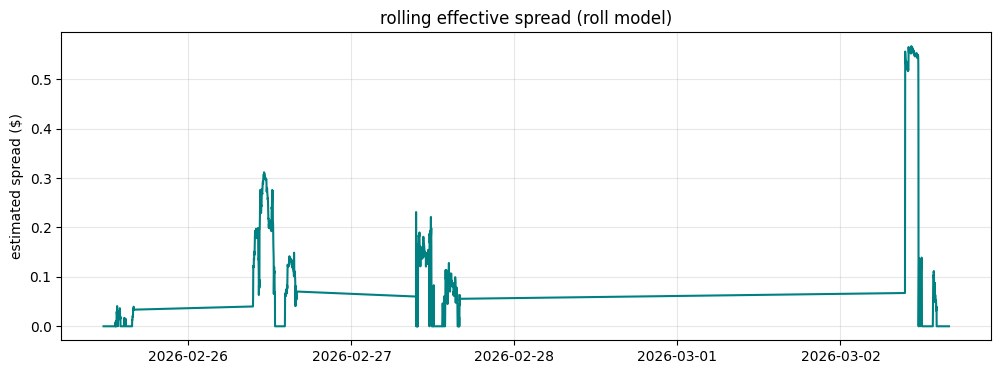

In [5]:
# plot the changing effective spread
plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(df['Datetime']), df['roll_spread'], color='teal')

plt.title('rolling effective spread (roll model)')
plt.ylabel('estimated spread ($)')
plt.grid(True, alpha=0.3)
plt.show()